# Curating samples from the xView 

- sample from promising images
- cross-check with existing annotations
- output for annotating the (missing label) 'road'


In [1]:
# re-loads code before cell execution, so if sth changes it will propagate:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys

import time as tm
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image
from functools import partial

sys.path.append('..')

import src.plotting as splo
import src.data_utils as sdut
import src.geom_utils as sgut

## Set up namespace, e.g. point to data

In [3]:
data_path = '../data/xView-train_images-subset/'
label_file = '../../xView_train.geojson'

out_path = '../data/xView/to_annotate/'

In [4]:
labelnames_di = {
    11:'Fixed-wing Aircraft', 12:'Small Aircraft', 13:'Passenger/Cargo Plane', 15:'Helicopter',
    17:'Passenger Vehicle', 18:'Small Car', 19:'Bus', 20:'Pickup Truck', 21:'Utility Truck',
    23:'Truck', 24:'Cargo Truck', 25:'Truck Tractor w/ Box Trailer', 26:'Truck Tractor',27:'Trailer',
    28:'Truck Tractor w/ Flatbed Trailer', 29:'Truck Tractor w/ Liquid Tank', 32:'Crane Truck',
    33:'Railway Vehicle', 34:'Passenger Car', 35:'Cargo/Container Car', 36:'Flat Car', 37:'Tank car',
    38:'Locomotive', 40:'Maritime Vessel', 41:'Motorboat', 42:'Sailboat', 44:'Tugboat', 45:'Barge',
    47:'Fishing Vessel', 49:'Ferry', 50:'Yacht', 51:'Container Ship', 52:'Oil Tanker',
    53:'Engineering Vehicle', 54:'Tower crane', 55:'Container Crane', 56:'Reach Stacker',
    57:'Straddle Carrier', 59:'Mobile Crane', 60:'Dump Truck', 61:'Haul Truck', 62:'Scraper/Tractor',
    63:'Front loader/Bulldozer', 64:'Excavator', 65:'Cement Mixer', 66:'Ground Grader', 71:'Hut/Tent',
    72:'Shed', 73:'Building', 74:'Aircraft Hangar', 76:'Damaged Building', 77:'Facility', 79:'Construction Site',
    83:'Vehicle Lot', 84:'Helipad', 86:'Storage Tank', 89:'Shipping container lot', 91:'Shipping Container',
    93:'Pylon', 94:'Tower'}
labelnames_di_ = {v:k for k,v in labelnames_di.items()}

car_set = set([17,18,20])
bus_truck_set = set([19,21,23,24,25,26,27,28])
vehicle_set = car_set & bus_truck_set


building_flag = lambda x: x == 73
car_flag = lambda x: x in car_set
bus_truck_flag = lambda x: x in bus_truck_set

In [5]:
def sample_xy( image_, num_samp, res= 128, seed= 11, rounds= 2, verbose= False):
    """
    Given an image (as a numpy array), sample random x,y coordinates for res by res crops, minding
    not to be too close to the edge or each other (within reason)
    """
    # NOTE: sampling is in numpy coordinates
    res_half = int( res/2)
    shift_min = int( res/5)
    xmax, ymax, _ = image_.shape
    np.random.seed( seed)
    # sample valid x and y coordinates (at least half-resolution away from edge):
    xs = res_half + np.random.uniform( xmax - res, size= num_samp)
    ys = res_half + np.random.uniform( ymax - res, size= num_samp)
    dfs = pd.DataFrame( {'xs': xs, 'ys': ys}).sort_values( by= 'xs').astype(int)
    # we don't want to sample points that are too close:
    for rd in range( rounds):        
        to_check = np.argwhere( abs( ( dfs['xs'] - np.roll( dfs['xs'], shift= 1))) < shift_min).reshape(-1)
        to_drop = []
        for index in to_check:
            if abs( dfs.iloc[[index-1,index]]['ys'].diff().values[-1]) < shift_min:
                if verbose:
                    print(f'{rd+1} round, removing as too close: {dfs.iloc[[index-1]].values} and {dfs.iloc[[index]].values}')
                to_drop.append( dfs.iloc[[index]].index[0])
        dfs.drop( labels= to_drop, axis= 0, inplace= True)
    # now add the target (numpy) bbox:
    dfs['bbox_np'] = dfs.apply( 
        lambda x: sgut.square_bbox_around( x['xs'], x['ys'], res= 128), axis= 1
    ).map(lambda x: [int(y) for y in x])
    dfs['bbox_ctx'] = dfs.apply( lambda x: sgut.center_on_bbox( x['bbox_np'], 256, xmax, ymax, fix_edge= True), axis= 1)
    dfs['bbox_context'] = dfs['bbox_ctx'].apply( lambda x: x[0]).map(lambda x: [int(y) for y in x])
    dfs['bbox_in_context'] = dfs['bbox_ctx'].apply( lambda x: x[1]).map(lambda x: [int(y) for y in x])
    # prepare space for pre-annotating:
    dfs['built_area'] = np.nan
    dfs['n_cars'] = np.nan
    dfs['n_bus_trucks'] = np.nan
    dfs['roads'] = np.nan
    return dfs.sort_values(by=['xs','ys']).reset_index(drop=True).drop( labels= ['bbox_ctx'], axis=1)

def to_magenta( arr, from_pix, to_pix, at_pix, axis):
    if axis== 'x':
        arr[from_pix:to_pix,at_pix,0] = 255
        arr[from_pix:to_pix,at_pix,1] = 0
        arr[from_pix:to_pix,at_pix,2] = 255
    elif axis=='y':
        arr[at_pix,from_pix:to_pix,0] = 255
        arr[at_pix,from_pix:to_pix,1] = 0
        arr[at_pix,from_pix:to_pix,2] = 255        
    return arr

def draw_bbox( crop, bbox_in_context):
    x1, y1, x2, y2 = bbox_in_context
    crop = to_magenta( crop, x1, x2, y1, 'x')
    crop = to_magenta( crop, y1, y2, x2, 'y')
    crop = to_magenta( crop, x1, x2, y2, 'x')
    crop = to_magenta( crop, y1, y2, x1, 'y')
    return crop

def mark_c( crop):
    x1, y1, x2, y2 = (30, 20, 45, 35)
    crop = to_magenta( crop, x1, x2, y1, 'x')
    #crop = to_magenta( crop, x1, x2, y2, 'x')
    crop = to_magenta( crop, y1, y2, x1, 'y')
    crop = to_magenta( crop, y1, y2, x2, 'y')
    return crop

def mark_b( crop):
    x1, y1, x2, y2 = (60, 20, 75, 33)
    crop = to_magenta( crop, x1, x2, y1, 'x')
    crop = to_magenta( crop, x1+1, x2-1, y2, 'x')
    crop = to_magenta( crop, y1 + 5, y2, x1 + int((x2-x1)/2), 'y')
    crop = to_magenta( crop, y1, y2-2, x1, 'y')
    crop = to_magenta( crop, y1, y2-2, x2, 'y')
    return crop

def intersecting_df_slice( df_, bbox_np):
    return df_.loc[ 
        df_[ 'bbox_np'].apply( lambda x: sgut.get_area( sgut.intersection( bbox_np, x))) > 0, :
    ]

def save_to_annotate( image_, dfs_row, df_, out_path= None):
    """
    With image, the candidate sample location, and reference existing annotations (in a dataframe) for 
    that image, create a ready-to-annotate sample (that is the res-by-res with wider box around for
    visual inspection, for easier identification of roads; bbox is drawn around the target sample).
    Also, cross-check with existing annotations (cars & buildings), and correct as needed for our 
    purpose (e.g. for a car it needs to be)
    """
    name_, bbox_context, bbox_in_context, bbox_np = dfs_row[['im_name','bbox_context','bbox_in_context','bbox_np']]
    df__ = intersecting_df_slice( df_, bbox_np)
    intersection_ = partial( sgut.intersection, bbox_np)
    dfa = pd.DataFrame( {
        'car_flag': df__['car_flag'].values,
        'bus_truck_flag': df__['bus_truck_flag'].values,
        'building_flag': df__['building_flag'].values,
        'feature_area': df__['feature_area'].values,
        'intersection_area': df__['bbox_np'].map( intersection_).map( sgut.get_area).values,
    })
    built_area = dfa.loc[ dfa['building_flag']==1, 'intersection_area'].sum()
    n_cars = len(
        dfa.loc[ (dfa['car_flag']==1) & ( dfa['intersection_area'] > 0.9 * dfa['feature_area']) ]
    )
    n_bus_trucks = len(
        dfa.loc[ (dfa['bus_truck_flag']==1) & ( dfa['intersection_area'] > 0.9 * dfa['feature_area']) ]
    )
    crop = sgut.crop_to_bbox( image_, bbox_context).copy()
    crop = draw_bbox( crop, bbox_in_context)
    if n_cars + n_bus_trucks > 0:
        crop = mark_c( crop)
    if built_area > 0.25:
        crop = mark_b( crop)
    if out_path is not None:
        # for whatever reasons, pyplot-saved images do not work with pyannotate but PIL ones do:
        Image.fromarray( crop).save(f'{out_path}{name_}')
        return built_area, n_cars, n_bus_trucks
    else:
        return crop, df__, dfa

## Investigate data, try things out 

_**you can even add fancy markdown throughout to document things..?**_

In [6]:
label_li = sdut.from_json( label_file)['features']
df = pd.DataFrame([x['properties'] for x in label_li])
df.drop(
    labels= ['edited_by','cat_id','point_geom','grid_file','ingest_time'], axis= 1, inplace= True
)
df['cat'] = df['type_id'].map( labelnames_di)
df['bbox'] = df['bounds_imcoords'].map( lambda x: [int(y) for y in x.split(',')])
df['bbox_np'] = df['bbox'].map( sgut.bbox_np)
df['feature_area'] = df['bbox_np'].apply( sgut.get_area)
df['car_flag'] = df['type_id'].map( car_flag).astype(int)
df['bus_truck_flag'] = df['type_id'].map( bus_truck_flag).astype(int)
df['building_flag'] = df['type_id'].map( building_flag).astype(int)
df.head(3)

,bounds_imcoords,type_id,index_right,image_id,feature_id,cat,bbox,bbox_np,feature_area,car_flag,bus_truck_flag,building_flag
0,"2712,1145,2746,1177",73,2356,2355.tif,374410,Building,"[2712, 1145, 2746, 1177]","(1145, 2712, 1177, 2746)",1088,0,0,1
1,"2720,2233,2760,2288",73,2356,2355.tif,394393,Building,"[2720, 2233, 2760, 2288]","(2233, 2720, 2288, 2760)",2200,0,0,1
2,"2687,1338,2740,1399",73,2356,2355.tif,374031,Building,"[2687, 1338, 2740, 1399]","(1338, 2687, 1399, 2740)",3233,0,0,1


In [7]:
dfg = df.groupby('image_id').agg({
    'type_id': [ len, lambda x: len(set(x)), 
                lambda x: len([y for y in x if y in car_set]),
                lambda x: len([y for y in x if y in bus_truck_set]),
                lambda x: len([y for y in x if y == 73])]
}).droplevel(level=0,axis=1).rename( 
    columns= {'<lambda_0>': 'n_cats', 'len': 'n_labels', '<lambda_1>':'n_cars', '<lambda_2>':'n_bus_trucks', '<lambda_3>':'n_buildings'}
)
dfg.head(3)

,n_labels,n_cats,n_cars,n_bus_trucks,n_buildings
image_id,,,,,
10.tif,63,7,2,1,44
100.tif,135,3,62,7,66
102.tif,1965,9,346,25,1563


Now that we have some high-level understanding can choose poss interesting images

In [8]:
target_ims = dfg.loc[ dfg['n_cars']+dfg['n_bus_trucks']>300].index.tolist()
target_ims = [x for x in target_ims if os.path.exists(f'{data_path}{x}')]
print(f'{len(target_ims)} images')

216 images


In [18]:
sample_im_name = target_ims[1]
df_ = df.loc[ df['image_id']== sample_im_name]
image_ = np.array( Image.open(f'{data_path}{sample_im_name}'))#sdut.to_numpy( sdut.load_image( f'{data_path}{sample_im_name}'))
xmax, ymax, _ = image_.shape
figsize = ( int(xmax / 200), int( ymax/ 200))
sample_im_name

'1037.tif'

In [22]:
dfs = sample_xy( image_, 300, seed= 13)
dfs['im_name'] = [sample_im_name.replace('.tif',f'_{x}.png') for x in range(len(dfs))]
dfs.shape

(296, 10)

In [23]:
dfs.head(3)

,xs,ys,bbox_np,bbox_context,bbox_in_context,built_area,n_cars,n_bus_trucks,roads,im_name
0,82,127,"[18, 63, 146, 191]","[0, 0, 256, 256]","[18, 63, 146, 191]",NaN,NaN,NaN,NaN,1037_0.png
1,111,1661,"[47, 1597, 175, 1725]","[0, 1533, 256, 1789]","[47, 64, 175, 192]",NaN,NaN,NaN,NaN,1037_1.png
2,149,2385,"[85, 2321, 213, 2449]","[21, 2257, 277, 2513]","[64, 64, 192, 192]",NaN,NaN,NaN,NaN,1037_2.png


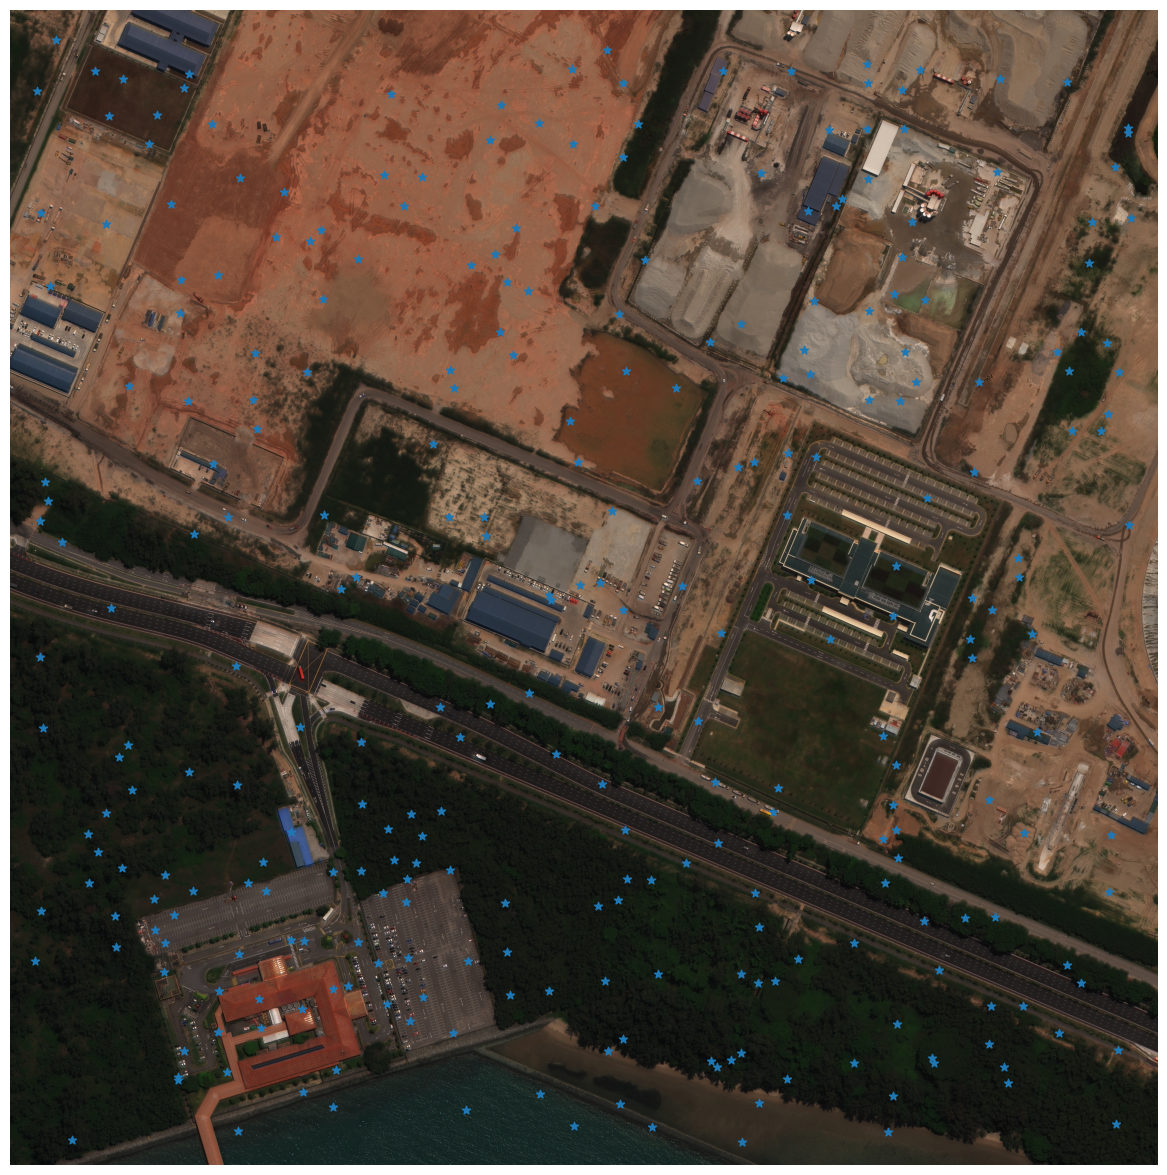

In [24]:
ax = splo.plot_single(image_, figsize= figsize)
ax.scatter(dfs['ys'], dfs['xs'], marker='*')

In [15]:
dfs.head(2)

,xs,ys,bbox_np,bbox_context,bbox_in_context,built_area,n_cars,n_bus_trucks,roads,im_name
0,65,1613,"[1, 1549, 129, 1677]","[0, 1485, 256, 1741]","[1, 64, 129, 192]",NaN,NaN,NaN,NaN,102_0.png
1,66,1445,"[2, 1381, 130, 1509]","[0, 1317, 256, 1573]","[2, 64, 130, 192]",NaN,NaN,NaN,NaN,102_1.png


<Axes: >

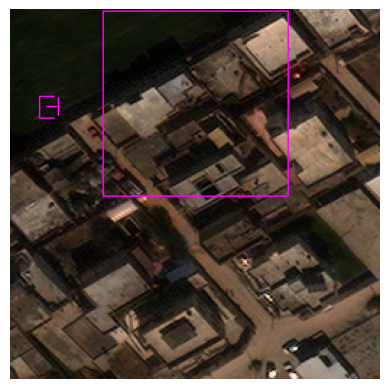

In [16]:
crop, df__, dfa = save_to_annotate( image_, dfs.loc[dfs.index[0]], df_)
splo.plot_single( crop)

In [25]:
start = tm.time()

for idx in dfs.index:
    dfs.loc[ idx, ['built_area','n_cars','n_bus_trucks']] = save_to_annotate( image_, dfs.loc[idx], df_, out_path= out_path)

dfs.to_csv(f'{out_path}labels.csv', index= False)    

print(f'Took {(tm.time() - start)/60} mins.')

Took 0.17191344499588013 mins.
